In [326]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.optimize as sco 
import seaborn as sns
from pandas_datareader import data as pdr
import random

In [140]:
daily_returns = pd.read_csv(
    "data/processed/daily_returns.csv",
    index_col=0,
    parse_dates=True
)

adj_close = pd.read_csv(
    "data/processed/adj_close.csv",
    index_col=0,
    parse_dates=True
)

cov_matrix = pd.read_csv(
    "data/processed/cov_matrix.csv",
    index_col=0
)

metrics_table = pd.read_csv(
    "data/processed/metrics_table.csv",
    index_col=0
)

daily_rfr = pd.read_csv(
    "data/processed/daily_risk_free_rate.csv",
    index_col = 0
)

In [141]:
annual_returns = daily_returns.mean() * 252
rf_annual_rate = float((daily_rfr * 252).mean().round(4).iloc[0])

In [184]:
portfolio_groups = {
    "Dom_Eq": ['SPY', 'QQQ', 'IWM'],
    "Intl_Eq": ['EFA', 'EEM'],
    "Fixed_Inc": ['AGG', 'TLT', 'LQD'],
    "Alt": ['GLD', 'VNQ'],
    "Factor": ['MTUM', 'VLUE', 'QUAL', 'USMV']
}
ticker_asset_class = {
    ticker: group
    for group, tickers in portfolio_groups.items()
    for ticker in tickers
}
asset_class = annual_returns.index.to_series().map(ticker_asset_class)
asset_class

AGG     Fixed_Inc
EEM       Intl_Eq
EFA       Intl_Eq
GLD           Alt
IWM        Dom_Eq
LQD     Fixed_Inc
MTUM       Factor
QQQ        Dom_Eq
QUAL       Factor
SPY        Dom_Eq
TLT     Fixed_Inc
USMV       Factor
VLUE       Factor
VNQ           Alt
dtype: str

In [143]:
## Functions ##
def portfolio_return(weights, returns):
    return np.dot(weights, returns)

def portfolio_volatility(weights, cov_matrix):
    return np.sqrt(weights.T @ cov_matrix @ weights)

def sharpe_ratio(weights, returns, cov_matrix, rf_annual_rate):
    port_returns = portfolio_return(weights, returns)
    port_volatility = portfolio_volatility(weights, cov_matrix)
    return (port_returns - rf_annual_rate) / port_volatility


In [218]:
## Equal Weight Portfolio ## 
num_of_assets = len(annual_returns)
equal_weights = np.array([1 / num_of_assets] * num_of_assets)
eq_returns = portfolio_return(equal_weights, annual_returns)
eq_volatility = portfolio_volatility(equal_weights, cov_matrix)
eq_sharpe = sharpe_ratio(equal_weights, annual_returns, cov_matrix, rf_annual_rate)

eq_weights_values = pd.Series(equal_weights, index=annual_returns.index).sort_values(ascending=False)

eq_weights_metrics = pd.Series([eq_returns.round(4), eq_volatility.round(4), eq_sharpe.round(4)], index = ['Returns', 'Volatility','Sharpe'])

print(eq_weights_values)
print(f"Return: {eq_returns:.4f}")
print(f"Volatility: {eq_volatility:.4f}")
print(f"Sharpe: {eq_sharpe:.4f}")


AGG     0.071429
EEM     0.071429
EFA     0.071429
GLD     0.071429
IWM     0.071429
LQD     0.071429
MTUM    0.071429
QQQ     0.071429
QUAL    0.071429
SPY     0.071429
TLT     0.071429
USMV    0.071429
VLUE    0.071429
VNQ     0.071429
dtype: float64
Return: 0.0913
Volatility: 0.1274
Sharpe: 0.4240


In [219]:
model_results =pd.DataFrame()
model_results['Eq_weights'] = pd.concat([eq_weights_values, eq_weights_metrics])
model_results

,Eq_weights
AGG,0.071429
EEM,0.071429
EFA,0.071429
GLD,0.071429
IWM,0.071429
LQD,0.071429
MTUM,0.071429
QQQ,0.071429
QUAL,0.071429
SPY,0.071429


In [220]:
## Min Variance ##
constraints = ({
    'type':'eq',
    'fun':lambda weights: np.sum(weights)-1
})

bounds = tuple((0,1) for _ in range(num_of_assets))
initial = equal_weights

min_variance_results = sco.minimize(
    portfolio_volatility,
    initial, 
    args = (cov_matrix),
    method = "SLSQP",
    bounds = bounds,
    constraints = constraints
)

min_var_weights = min_variance_results.x
min_var_weights

min_var_returns = portfolio_return(min_var_weights, annual_returns)
min_var_volatility = portfolio_volatility(min_var_weights, cov_matrix)
min_var_sharpe = sharpe_ratio(min_var_weights, annual_returns, cov_matrix, rf_annual_rate)

minvar_weights_values = pd.Series(min_var_weights, index=annual_returns.index).round(4)
minvar_weights_metrics = pd.Series([min_var_returns.round(4), min_var_volatility.round(4), min_var_sharpe.round(4)], index = ['Returns', 'Volatility','Sharpe'])
model_results['Min_Variance'] = pd.concat([minvar_weights_values, minvar_weights_metrics])

print(eq_weights_values)
print(f"Return: {min_var_returns:.4f}")
print(f"Volatility: {min_var_volatility:.4f}")
print(f"Sharpe: {min_var_sharpe:.4f}")

AGG     0.071429
EEM     0.071429
EFA     0.071429
GLD     0.071429
IWM     0.071429
LQD     0.071429
MTUM    0.071429
QQQ     0.071429
QUAL    0.071429
SPY     0.071429
TLT     0.071429
USMV    0.071429
VLUE    0.071429
VNQ     0.071429
dtype: float64
Return: 0.0120
Volatility: 0.0594
Sharpe: -0.4255


In [221]:
max_sharpe_results = sco.minimize(
    lambda weights, returns, cov, rf: -sharpe_ratio(weights, returns, cov, rf),
    initial, 
    args = (annual_returns, cov_matrix, rf_annual_rate),
    method = "SLSQP",
    bounds = bounds,
    constraints = constraints
)

sharpe_weights = max_sharpe_results.x
print(pd.Series(sharpe_weights, index=annual_returns.index).sort_values(ascending=False).round(4))

max_sharpe_return = portfolio_return(sharpe_weights, annual_returns)
max_sharpe_vol = portfolio_volatility(sharpe_weights, cov_matrix)
max_sharpe_ratio = sharpe_ratio(
    sharpe_weights,
    annual_returns,
    cov_matrix,
    rf_annual_rate
)

sharpe_weights_values = pd.Series(sharpe_weights, index=annual_returns.index).round(4)
sharpe_weights_metrics = pd.Series([max_sharpe_return.round(4), min_var_volatility.round(4), min_var_sharpe.round(4)], index = ['Returns', 'Volatility','Sharpe'])
model_results['Sharpe'] = pd.concat([sharpe_weights_values, sharpe_weights_metrics])

print(f"Return: {max_sharpe_return:.4f}")
print(f"Volatility: {max_sharpe_vol:.4f}")
print(f"Sharpe: {max_sharpe_ratio:.4f}")

GLD     0.5271
VLUE    0.4396
QQQ     0.0333
TLT     0.0000
VNQ     0.0000
IWM     0.0000
AGG     0.0000
MTUM    0.0000
EEM     0.0000
EFA     0.0000
LQD     0.0000
QUAL    0.0000
SPY     0.0000
USMV    0.0000
dtype: float64
Return: 0.1743
Volatility: 0.1395
Sharpe: 0.9821


## Constrained Optimization ## 
### Scenario: Asset Class Contraints for Conservative Portfolio

In [222]:
alt_mask = (asset_class == "Alt").astype(float).values
fixed_mask = (asset_class == "Fixed_Inc").astype(float).values
dom_eq_mask = (asset_class == "Dom_Eq").astype(float).values
int_eq_mask = (asset_class == "Intl_Eq").astype(float).values
factor_mask = (asset_class == "Factor").astype(float).values

In [223]:
alt_equity_cap = 0.15
fixed_eq_cap = 0.30
dom_eq_cap = 0.30
int_eq_cap = 0.15
factor_cap = 0.15

In [224]:
constraints = [
    {"type": "eq", "fun" : lambda w: np.sum(w) - 1},
    {"type": "ineq", "fun" : lambda w: alt_equity_cap - np.dot(w, alt_mask)},
    {"type": "ineq", "fun" : lambda w: fixed_eq_cap - np.dot(w, fixed_mask)},
    {"type": "ineq", "fun" : lambda w: dom_eq_cap - np.dot(w, dom_eq_mask)},
    {"type": "ineq", "fun" : lambda w: int_eq_cap - np.dot(w, int_eq_mask)},
    {"type": "ineq", "fun" : lambda w: factor_cap - np.dot(w, factor_mask)}
]
def negative_sharpe(weights, returns, cov_matrix, rf):
    return -sharpe_ratio(weights, returns, cov_matrix, rf)

In [238]:
Asset_const_sharpe = sco.minimize(
    negative_sharpe,
    initial, 
    args = (annual_returns, cov_matrix, rf_annual_rate),
    method = "SLSQP",
    bounds = bounds,
    constraints = constraints
)

Asset_const_sharpe_weights = Asset_const_sharpe.x

ac_sharpe_return = portfolio_return(Asset_const_sharpe_weights, annual_returns)
ac_sharpe_vol = portfolio_volatility(Asset_const_sharpe_weights, cov_matrix)
ac_sharpe_ratio = sharpe_ratio(
    Asset_const_sharpe_weights,
    annual_returns,
    cov_matrix,
    rf_annual_rate
)

ac_sharpe_weight_values = pd.Series(Asset_const_sharpe_weights, index = annual_returns.index).round(4)
ac_sharpe_metrics = pd.Series([ac_sharpe_return, ac_sharpe_vol, ac_sharpe_ratio], index = ['Returns', 'Volatility','Sharpe'])
model_results['Asset_Class_Constrained'] = pd.concat([ac_sharpe_weight_values, ac_sharpe_metrics])

print(pd.Series(Asset_const_sharpe_weights, index=annual_returns.index).sort_values(ascending=False).round(4))
print(f"Return: {ac_sharpe_return:.4f}")
print(f"Volatility: {ac_sharpe_vol:.4f}")
print(f"Sharpe: {ac_sharpe_ratio:.4f}")

QQQ     0.2795
AGG     0.2500
GLD     0.1500
VLUE    0.1500
EFA     0.1500
SPY     0.0205
LQD     0.0000
EEM     0.0000
IWM     0.0000
MTUM    0.0000
QUAL    0.0000
TLT     0.0000
USMV    0.0000
VNQ     0.0000
dtype: float64
Return: 0.1180
Volatility: 0.1241
Sharpe: 0.6501


In [226]:
## Constrained Optimization ##
### Scenario: Asset Concentration Contraints for Conservative Portfolio

In [239]:
model_results

,Eq_weights,Min_Variance,Sharpe,Asset_Class_Constrained
AGG,0.071429,0.8855,0.0000,0.250000
EEM,0.071429,0.0000,0.0000,0.000000
EFA,0.071429,0.0000,0.0000,0.150000
GLD,0.071429,0.0041,0.5271,0.150000
IWM,0.071429,0.0000,0.0000,0.000000
LQD,0.071429,0.0000,0.0000,0.000000
MTUM,0.071429,0.0138,0.0000,0.000000
QQQ,0.071429,0.0000,0.0333,0.279500
QUAL,0.071429,0.0000,0.0000,0.000000
SPY,0.071429,0.0000,0.0000,0.020500


## Efficient Frontier 

In [291]:
portfolios = 1000
assets = len(annual_returns)

random_matrix = np.random.random((portfolios, assets))
random_weights = random_matrix / random_matrix.sum(axis = 1, keepdims = True)

weights_frame = pd.DataFrame(
    random_weights,
    columns = annual_returns.index
)
weights_frame

,AGG,EEM,EFA,GLD,IWM,LQD,MTUM,QQQ,QUAL,SPY,TLT,USMV,VLUE,VNQ
0,0.058441,0.118300,0.020657,0.113043,0.084627,0.066891,0.111095,0.079393,0.045357,0.114532,0.009495,0.030441,0.043316,0.104411
1,0.093961,0.048208,0.107433,0.096547,0.091684,0.101713,0.028332,0.060524,0.085460,0.004848,0.114718,0.113683,0.007075,0.045815
2,0.068707,0.108146,0.060285,0.080301,0.101197,0.011391,0.019206,0.105634,0.030450,0.112659,0.013566,0.109194,0.094802,0.084463
3,0.066145,0.139041,0.053936,0.052965,0.062355,0.112564,0.115022,0.065022,0.034385,0.041459,0.090055,0.040250,0.060063,0.066739
4,0.108576,0.050305,0.118444,0.074300,0.072081,0.070318,0.123699,0.025319,0.033595,0.059564,0.115263,0.097644,0.049373,0.001517
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.053470,0.124802,0.036302,0.071707,0.086334,0.023067,0.114645,0.118815,0.082462,0.063097,0.042516,0.036414,0.058698,0.087670
996,0.122292,0.125618,0.146048,0.112977,0.018519,0.109888,0.012228,0.012265,0.088236,0.020021,0.123233,0.098595,0.001140,0.008940
997,0.038805,0.038491,0.013158,0.153733,0.122149,0.068625,0.043796,0.115934,0.118917,0.075204,0.039472,0.094892,0.044168,0.032656
998,0.040927,0.029058,0.142373,0.114826,0.043979,0.117827,0.088162,0.111934,0.107447,0.030326,0.017839,0.107038,0.021872,0.026392


In [305]:
frontier_metrics = []

for _, weights in weights_frame.iterrows():
    weights = weights.values
    returns = portfolio_return(weights, annual_returns)
    volatility = portfolio_volatility(weights, cov_matrix)

    if volatility == 0:
        sharpe = np.nan
    else:
        sharpe = (returns - rf_annual_rate) / volatility

    frontier_metrics.append([returns, volatility, sharpe])
frontier_plot_data = np.array(frontier_metrics)
plot_df = pd.DataFrame(frontier_plot_data, columns = ['returns','volatility','sharpe'])


In [ ]:
sns.scatterplot(x = 'volatility', y = 'returns', hue = 'sharpe', color='gold', edgecolors='black', alpha = 0.8, data = plot_df)

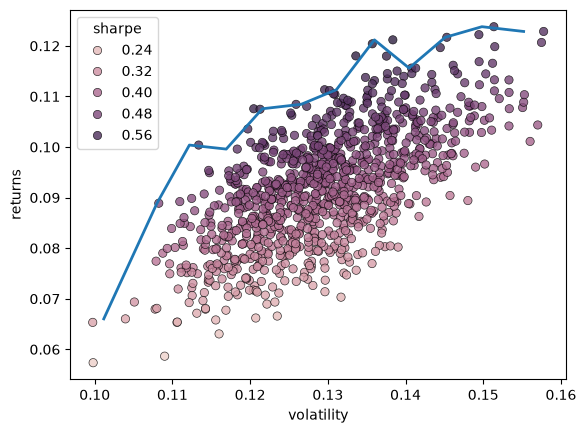

In [331]:
frontier = (
    plot_df
    .assign(vol_bin=pd.cut(plot_df["volatility"], bins=12))
    .groupby("vol_bin", observed=True)
    .agg({
        "volatility": "mean",
        "returns": "max"
    })
    .dropna()
)
sns.scatterplot(x = 'volatility', y = 'returns', hue = 'sharpe', color='gold', edgecolors='black', alpha = 0.8, data = plot_df)
plt.plot(frontier["volatility"], frontier["returns"], linewidth=2)